# Visualization to get the data

### Setup for Visuals

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In this file I just try plotting random stuff to see with what values I am working to get a better sense of the data.

Text(0.5, 1.0, 'Sexual Orientation by Gender')

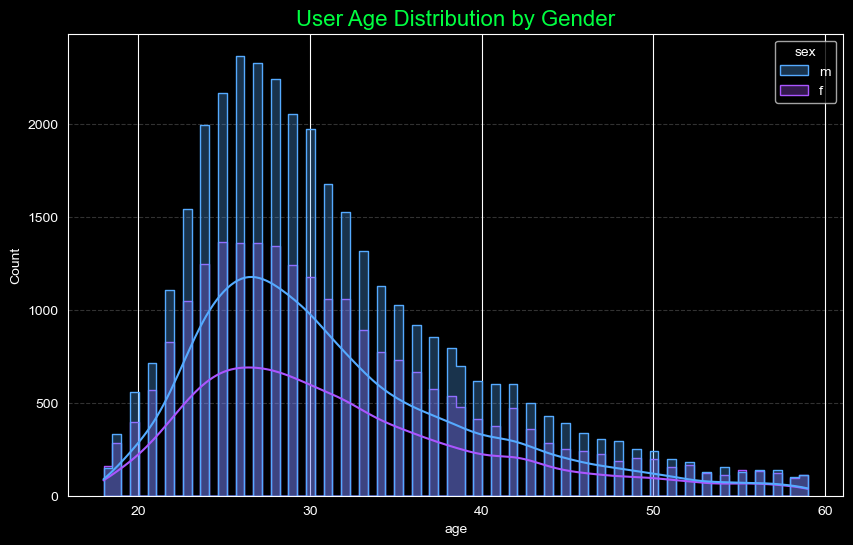

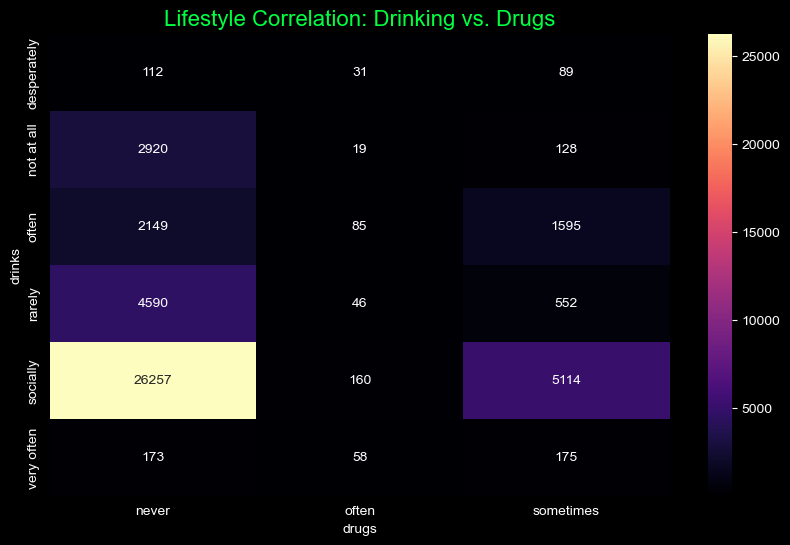

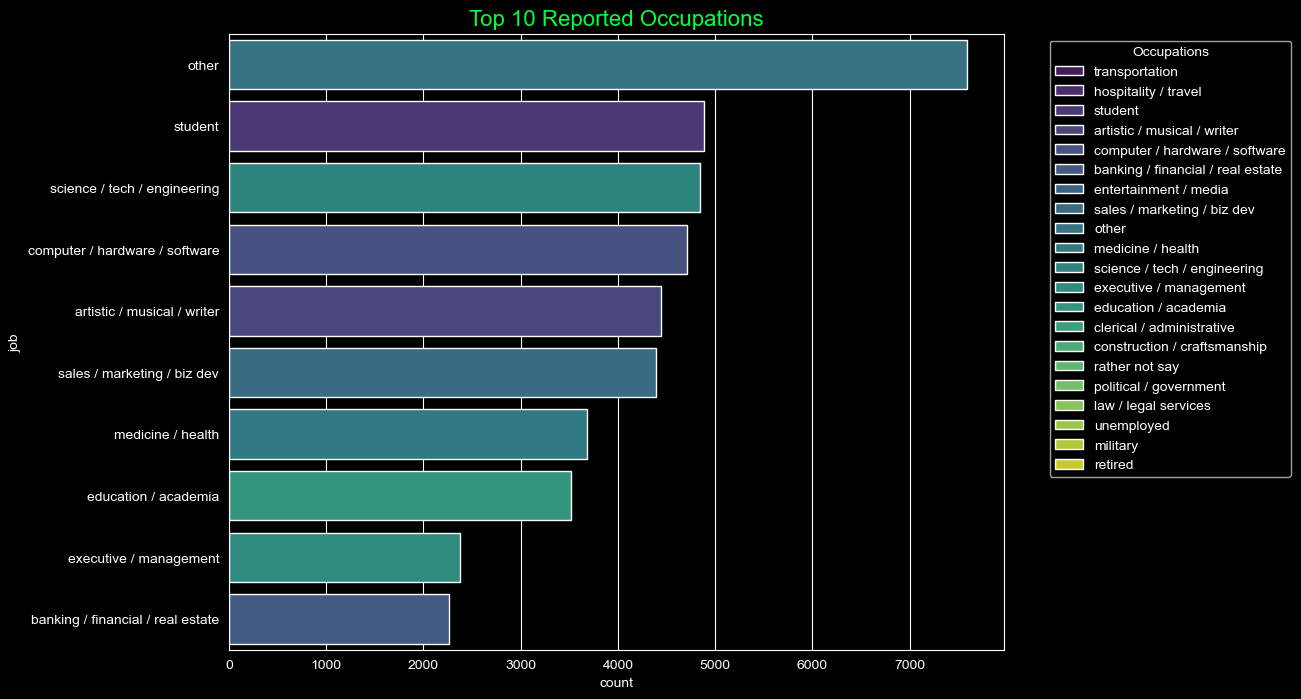

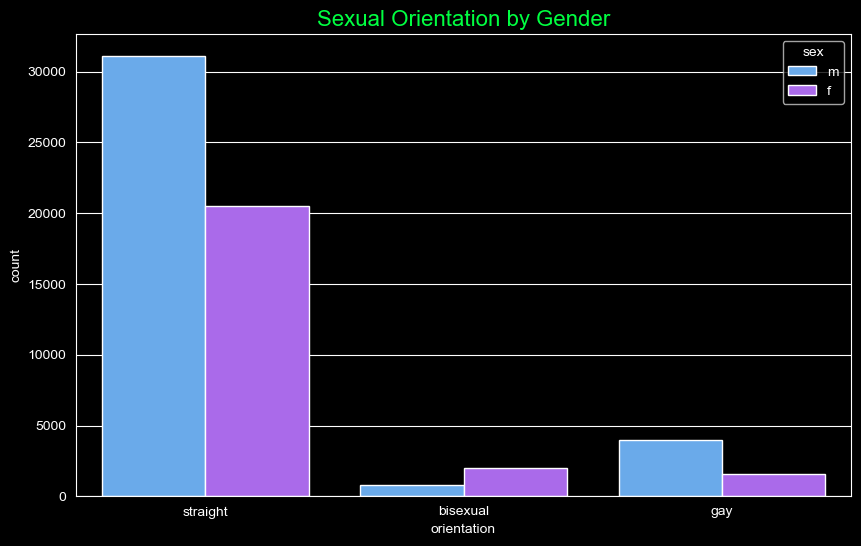

In [4]:
profiles = pd.read_csv('../Dataset/okcupid_profiles.csv')

# Style I found interesting (Needs maybe more friendly data visuals)
plt.style.use('dark_background')
accent_neon = '#00FF41'
sns.set_palette("magma")

# 1. Age Distribution
plt.figure(figsize=(10, 6))
gender_order = ['m', 'f']
sns.histplot(data=profiles[~profiles['age'].between(60,200)], x='age', hue='sex', hue_order=gender_order, kde=True, element="step", alpha=0.3, palette='cool')
plt.title('User Age Distribution by Gender', fontsize=16, color=accent_neon)
plt.grid(axis='y', linestyle='--', alpha=0.2)
#Needed some data cleaning, deleted outliers, and put in the order so female is more visible

# 2. Lifestyle Heatmap (Drinks vs Drugs)
habit_pivot = pd.crosstab(profiles['drinks'], profiles['drugs'])
plt.figure(figsize=(10, 6))
sns.heatmap(habit_pivot, annot=True, fmt="d", cmap="magma")
plt.title('Lifestyle Correlation: Drinking vs. Drugs', fontsize=16, color=accent_neon)
#Looks solid on first try

# 3. Top 10 Occupations (Without cleaning the data)
plt.figure(figsize=(10, 8))
job_order = profiles['job'].value_counts().iloc[:10].index
sns.countplot(y='job',hue='job', data=profiles, order=job_order, palette="viridis")
plt.title('Top 10 Reported Occupations', fontsize=16, color=accent_neon)
plt.legend(title='Occupations', bbox_to_anchor=(1.05, 1), loc='upper left')
#Tried fixing the legend to show only the jobs in the plot, could not reach what I wanted, tidied up the graph a bit

# 4. Orientation & Gender
plt.figure(figsize=(10, 6))
sns.countplot(data=profiles, x='orientation', hue='sex', palette="cool")
plt.title('Sexual Orientation by Gender', fontsize=16, color=accent_neon)


['working on college/university' 'working on space camp'
 'graduated from masters program' 'graduated from college/university'
 'working on two-year college' nan 'graduated from high school'
 'working on masters program' 'graduated from space camp'
 'college/university' 'dropped out of space camp'
 'graduated from ph.d program' 'graduated from law school'
 'working on ph.d program' 'two-year college'
 'graduated from two-year college' 'working on med school'
 'dropped out of college/university' 'space camp'
 'graduated from med school' 'dropped out of high school'
 'working on high school' 'masters program' 'dropped out of ph.d program'
 'dropped out of two-year college' 'dropped out of med school'
 'high school' 'working on law school' 'law school'
 'dropped out of masters program' 'ph.d program'
 'dropped out of law school' 'med school']
['undergrad' 'space camp' 'post-grad' 'not specified' 'high school'
 'dropped out']
edu_cleaned
undergrad        33299
post-grad        15140
not sp

Text(0.5, 1.0, 'Class Balance: Education Buckets')

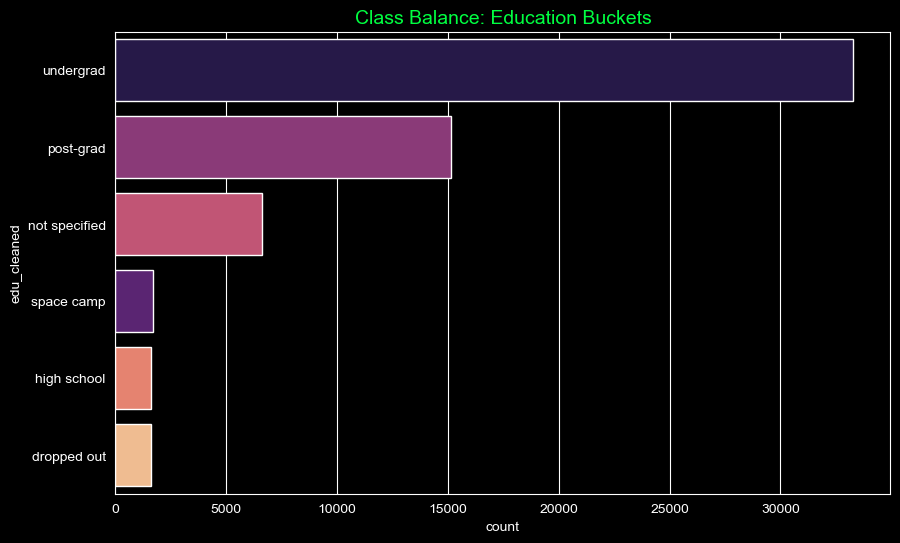

In [13]:
# 5 Education Level
print(profiles['education'].unique()) #Too many types of values, try to simplify into groups
#Functino to segment it into different groups
def segment_education(status):
    # Handle NaNs first
    if pd.isna(status):
        return 'not specified'
    status = status.lower()
    # 1. Joke / Noise Category
    if 'space camp' in status:
        return 'space camp'
    # 2. Dropped Out (captures any dropout regardless of level)
    if 'dropped out' in status:
        return 'dropped out'
    # 3. Post-Graduate (Highest Tier)
    if any(edu in status for edu in ['masters', 'ph.d', 'law school', 'med school']):
        return 'post-grad'
    # 4. Undergraduate / College
    if any(edu in status for edu in ['college', 'university', 'two-year college']):
        return 'undergrad'
    # 5. High School
    if 'high school' in status:
        return 'high school'

    return 'other'

profiles['edu_cleaned'] = profiles['education'].apply(segment_education)
print(profiles['edu_cleaned'].value_counts())
plt.figure(figsize=(10, 6))
order = profiles['edu_cleaned'].value_counts().index
sns.countplot(data=profiles, y='edu_cleaned', hue='edu_cleaned', palette='magma', order=order)
plt.title('Class Balance: Education Buckets', color=accent_neon, fontsize=14)


Unfortunately its now looking good for the first problem I wanted to solve, the undergrad class is way too overrepresented. I still want to check the lexical diversity to see
if the project may still be viable, or to try and find a solution to this.

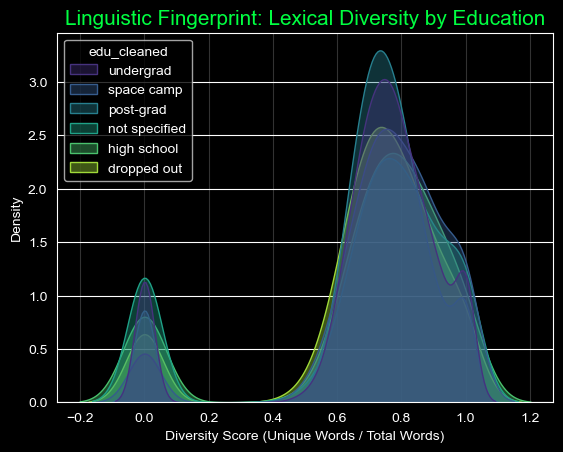

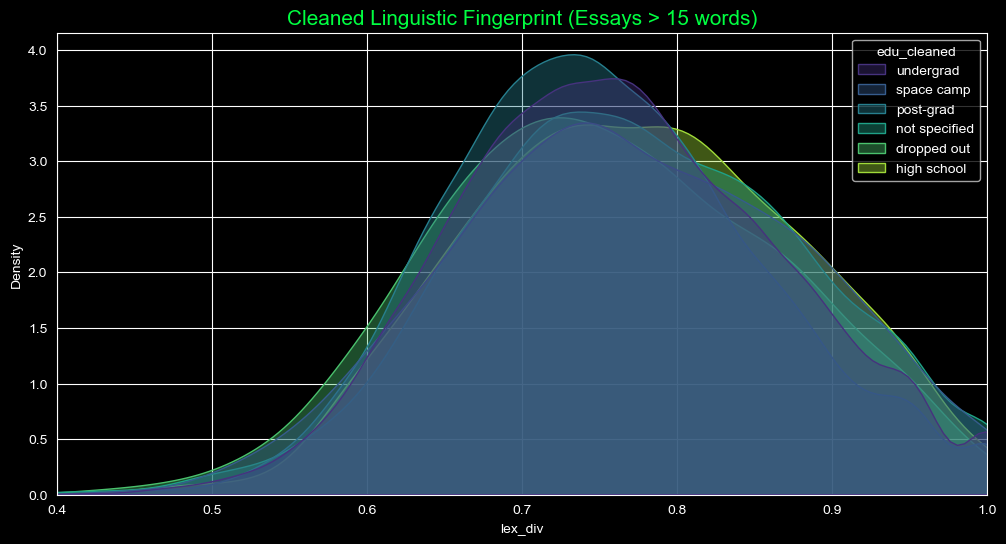

In [16]:
# 6 Lexical diversity
def get_lexical_diversity(text):
    if pd.isna(text) or text == "": return 0
    words = str(text).lower().split()
    if len(words) == 0: return 0
    return len(set(words)) / len(words)

# Apply to the self-summary essay
profiles['lex_div'] = profiles['essay0'].apply(get_lexical_diversity)

sns.kdeplot(data=profiles, x='lex_div', hue='edu_cleaned', fill=True, common_norm=False, palette='viridis', alpha=0.4)

plt.title('Linguistic Fingerprint: Lexical Diversity by Education', color='#00FF41', fontsize=15)
plt.xlabel('Diversity Score (Unique Words / Total Words)')
plt.ylabel('Density')
plt.grid(axis='x', alpha=0.2)
plt.show()

# Filter out the 'zeros' and very short essays to see the 'true' writing styles
refined_df = profiles[(profiles['lex_div'] > 0.1) & (profiles['essay0'].str.split().str.len() > 15)]

plt.figure(figsize=(12, 6))
sns.kdeplot(data=refined_df, x='lex_div', hue='edu_cleaned',
            fill=True, common_norm=False, palette='viridis', alpha=0.4)

plt.title('Cleaned Linguistic Fingerprint (Essays > 15 words)', color='#00FF41', fontsize=15)
plt.xlim(0.4, 1.0) # Zoom in on the meaningful area
plt.show()